# Face detection
In this notebook we will use an object detection network to detect faces in images. In this case, we will only need positive samples. The network will be fed with images that contain faces and the coordinates of their bounding boxes. The negative samples are implicitly the rest of the image patches without faces.

Since the architecture and the training of an object detection network is quite complex, you are going to download and learn to use a You Look Only Once (YOLO) network. This notebook reproduces all the steps to build an object detection system from scratch. 

Global requirements:
- git

Python requirements:
- matplotlib
- pytorch
- glob
- opencv
- shapely


## The problem
You have to develop a solution to detect faces in images and to identify if they are using a mask. To this end, you have a dataset of more than 800 annotated images. There are three classes in this dataset: without mask, with mask, and mask weared incorrect.

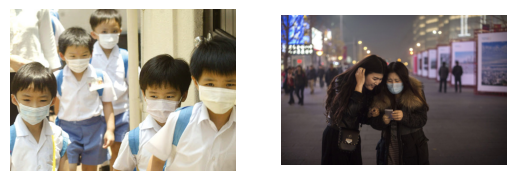

In [2]:
import matplotlib.pyplot as plt


im1 = plt.imread('res/facemask/images/train/maksssksksss230.png')
im2 = plt.imread('res/facemask/images/train/maksssksksss345.png')

fig, ax = plt.subplots(1,2)
ax[0].imshow(im1)
ax[0].axis('off')
ax[1].imshow(im2)
ax[1].axis('off')
plt.show()

The images are annotated in XML following the VOC format:
```
<annotation>
    <folder>images</folder>
    <filename>maksssksksss345.png</filename>
    <size>
        <width>400</width>
        <height>267</height>
        <depth>3</depth>
    </size>
    <segmented>0</segmented>
    <object>
        <name>with_mask</name>
        <pose>Unspecified</pose>
        <truncated>0</truncated>
        <occluded>0</occluded>
        <difficult>0</difficult>
        <bndbox>
            <xmin>186</xmin>
            <ymin>110</ymin>
            <xmax>218</xmax>
            <ymax>142</ymax>
        </bndbox>
    </object>
    <object>
        <name>without_mask</name>
        <pose>Unspecified</pose>
        <truncated>0</truncated>
        <occluded>0</occluded>
        <difficult>0</difficult>
        <bndbox>
            <xmin>148</xmin>
            <ymin>109</ymin>
            <xmax>182</xmax>
            <ymax>136</ymax>
        </bndbox>
    </object>
</annotation>
```

The images for training are stored in the directory `res/facemask/images/train` and the images for validation, in `res/facemask/images/val`. The annotations are stored in the `res/facemask/labels/train` and `res/facemask/labels/val`. The name of the image and its corresponding annotation file is the same but the extension.

The following function reads a xml and returns a list with the coordinates of all the bounding boxes and their corresponding classes:

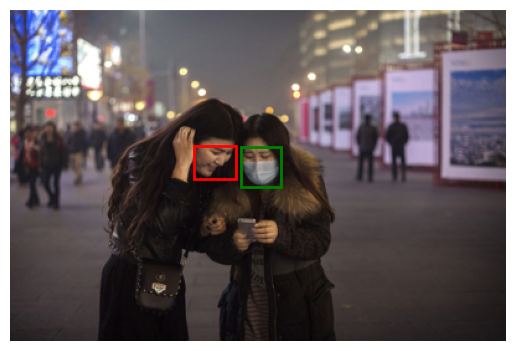

In [3]:
from xml.dom.minidom import parse
from matplotlib.patches import Rectangle
import numpy as np


FACE_MASK_CLASSES = {
    'with_mask': 0,
    'mask_weared_incorrect': 1,
    'without_mask': 2
}
COLORS = {
    0: 'green',
    1: 'purple',
    2: 'red',
}

def parse_xml_voc(filename):
    document = parse(filename)
    
    xmin = document.getElementsByTagName("xmin")
    ymin = document.getElementsByTagName("ymin")
    xmax = document.getElementsByTagName("xmax")
    ymax = document.getElementsByTagName("ymax")
    name = document.getElementsByTagName("name")

    data = np.zeros((len(xmin), 5)) # Label + 4 coordinates
    for idx in range(len(xmin)):
        data[idx, 0] = FACE_MASK_CLASSES[name[idx].firstChild.nodeValue]
        data[idx, 1] = int(xmin[idx].firstChild.nodeValue)
        data[idx, 2] = int(ymin[idx].firstChild.nodeValue)
        data[idx, 3] = int(xmax[idx].firstChild.nodeValue)
        data[idx, 4] = int(ymax[idx].firstChild.nodeValue)
    
    return data

data = parse_xml_voc('res/facemask/labels/train/maksssksksss345.xml')

plt.imshow(im2)
plt.axis('off')
for box in data:
    label = box[0]
    x1, y1, x2, y2 = box[1:]
    # Rectangle( (xmin, ymin), width, height, ...)
    plt.gca().add_patch(Rectangle((x1, y1), x2-x1, y2-y1, 
                              edgecolor=COLORS[label], 
                              facecolor='none',
                              lw=2))
plt.show()
                    

## Step 1: Prepare the environment

You can execute command line instructions from the Jupyter environment. In this notebook, you are going to download the source code of the official YOLOv7 network from github and install its requirements.

In [4]:
!git clone https://github.com/WongKinYiu/yolov7.git

fatal: destination path 'yolov7' already exists and is not an empty directory.


In [5]:
!python3 -m pip install -r yolov7/requirements.txt

In [6]:
import sys
import torch
import numpy as np
import cv2

print("Python:", sys.executable)
print("Python version:", sys.version)
print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")
print("NumPy:", np.__version__)
print("OpenCV:", cv2.__version__)

Python: /home/hugo/CVII/cv/bin/python
Python version: 3.10.12 (main, Mar  3 2026, 11:56:32) [GCC 11.4.0]
Torch: 2.5.1+cu121
CUDA available: True
GPU: NVIDIA GeForce GTX 1650
NumPy: 1.23.5
OpenCV: 4.11.0


## Step 2: Prepare the dataset
For each sample, the YOLO network receives a pair of files: the image and its corresponding annotations in a txt file. The name of the image and the txt file should be the same. Each line in the txt file contains the annotation of a region following this format: 
```
label xc yc w h
````
where `xc` and `yc` are the coordinates of the center of a bounding box and `w`and  `h` are its width and height. These four values are relative to size of the image. For example, if the size of the image is 1000x1000 and the center of a bounding box is at (500,500), the relative values are (0.5, 0.5).

### Exercise
Write a function to convert a file from the VOC format to the YOLO format and write it in a specific directory.


**Exercise — VOC to YOLO conversion:** I read each bounding box from the VOC XML (absolute pixel coordinates `xmin, ymin, xmax, ymax`), obtain the image dimensions via `plt.imread`, compute the normalised center coordinates and dimensions required by YOLO (`xc, yc, w, h` ∈ [0,1]), and write every annotation line as `label xc yc w h` to the output txt file.

In [7]:
import csv

def voc_to_yolo(in_image, in_annotations, out_annotations):
    document = parse(in_annotations)
    
    xmin = document.getElementsByTagName("xmin")
    ymin = document.getElementsByTagName("ymin")
    xmax = document.getElementsByTagName("xmax")
    ymax = document.getElementsByTagName("ymax")
    name = document.getElementsByTagName("name")

    f = open(out_annotations, 'w')
    writer = csv.writer(f, delimiter=' ')
    
    img = plt.imread(in_image)
    img_h, img_w = img.shape[:2]  # Get image dimensions for normalization
    
    for idx in range(len(xmin)):
        # Get class label
        label = FACE_MASK_CLASSES[name[idx].firstChild.nodeValue]
        
        # Read absolute pixel coordinates from VOC format
        x1 = int(xmin[idx].firstChild.nodeValue)
        y1 = int(ymin[idx].firstChild.nodeValue)
        x2 = int(xmax[idx].firstChild.nodeValue)
        y2 = int(ymax[idx].firstChild.nodeValue)
        
        # Convert to YOLO format: center coords + width/height, all normalized to [0,1]
        xc = ((x1 + x2) / 2) / img_w
        yc = ((y1 + y2) / 2) / img_h
        w  = (x2 - x1) / img_w
        h  = (y2 - y1) / img_h
        
        writer.writerow([label, xc, yc, w, h])
    f.close()

voc_to_yolo('res/facemask/images/train/maksssksksss345.png','res/facemask/labels/train/maksssksksss345.xml','res/facemask/labels/train/maksssksksss345.txt')


Check the contents of the file (only works in linux/osx):

In [8]:
%cat res/facemask/labels/train/maksssksksss345.txt

0 0.505 0.47191011235955055 0.08 0.1198501872659176
2 0.4125 0.45880149812734083 0.085 0.10112359550561797


### Exercise

Transform all the xml in the validation and train datasets into YOLO format. Store the txt files in the same directories as the xml files (`res/facemask/labels/train` or `res/facemask/labels/val`).

*Hint*: in previous notebooks we have used the library `glob` for reading files from a directory.

**Exercise — Batch conversion:** I use `glob` to collect every `.xml` file in both `train` and `val` label directories, derive the matching image path by swapping `labels` → `images` and the extension to `.png`, and call the previously defined `voc_to_yolo` function for each pair.

In [9]:
import glob
import os

# Iterate over both splits and convert every XML annotation to YOLO txt format
for split in ['train', 'val']:
    xml_files = glob.glob(f'res/facemask/labels/{split}/*.xml')
    for xml_file in xml_files:
        base = os.path.splitext(xml_file)[0]          # path without extension
        # Corresponding image is in the 'images' subtree with .png extension
        img_file = base.replace('labels', 'images') + '.png'
        out_txt  = base + '.txt'
        voc_to_yolo(img_file, xml_file, out_txt)

print('Conversion complete.')


Conversion complete.


Check the creation of files (only works in linux/osx):

In [10]:
!echo "Number of xml files:"
%ls res/facemask/labels/*/*.xml |wc -l
!echo "Number of txt files:"
%ls res/facemask/labels/*/*.txt |wc -l

Number of xml files:
853
Number of txt files:
853


## Step 2: Set up training

You will not need to write any code to train a YOLO network. Instead, you will use a predefined architecture and tweak it to fit your problem. 

This step requires that you copy and edit some files in your filesystem using a text editor outside the Jupyter environment.

### Exercise
Follow the next steps to set up the training stage:

1. Create a file `res/facemask/facemask.yaml` where you will define the absolute path to your files  and the features of your dataset as follows:

```
train: /absolute/path/to/res/facemask/images/train
val: /absolute/path/to/res/facemask/images/val

nc: 3
names: ['with mask', 'mask weared incorrect', 'without mask']
```
**Important**: the training will not work unless you write in this file the **actual absolute path** to your files. 

2. Define the architecture of your network and adapt it to the number of classes of this problem. Copy the file `yolov7/cfg/training/yolov7.yaml`to  `res/facemask/yolov7_facemask.yaml` and edit the number of classes (3 instead of 80).

Run the following lines to check the files (only works in linux/osx).

**Exercise — Dataset & architecture YAML setup:**

I need to create two configuration files outside this notebook (using a text editor or the terminal):

1. **`res/facemask/facemask.yaml`** — dataset config with the absolute paths to the train/val image folders and the 3 class names.
2. **`res/facemask/yolov7_facemask.yaml`** — architecture config copied from `yolov7/cfg/training/yolov7.yaml` with `nc` changed from `80` to `3`.

**WSL example commands:**
```bash
# 1. Get the absolute path to the project root
pwd

# 2. Create facemask.yaml  (replace /absolute/path accordingly)
cat > res/facemask/facemask.yaml << 'EOF'
train: /absolute/path/to/res/facemask/images/train
val:   /absolute/path/to/res/facemask/images/val
nc: 3
names: ['with_mask', 'mask_weared_incorrect', 'without_mask']
EOF

# 3. Copy and patch the architecture file
cp yolov7/cfg/training/yolov7.yaml res/facemask/yolov7_facemask.yaml
sed -i 's/^nc: 80/nc: 3/' res/facemask/yolov7_facemask.yaml
```

In [11]:
!echo "Checking files:\n\n=== facemask.yaml ===\n"
%cat res/facemask/facemask.yaml

Checking files:\n\n=== facemask.yaml ===\n
cat: res/facemask/facemask.yaml: No such file or directory


In [12]:
!echo "=== yolov7_facemask.yaml ===\n"
!head -n 10 res/facemask/yolov7_facemask.yaml

=== yolov7_facemask.yaml ===\n
head: cannot open 'res/facemask/yolov7_facemask.yaml' for reading: No such file or directory


## Step 3: Train the network

Once both the architecture and dataset were defined, you can train the YOLO network. To this end, you are going to use the script `yolov7/train.py` and the weights of a pretrained network (`res/facemask/yolov7_weights.pt`). 

### Exercise
Run the following command to train the YOLO network that you have configured for 3 epochs. 

**Important**: check that all the files are stored in the appropriate paths. 

**Note**: the training can last several minutes (even hours) if it is run on a CPU. 

The results of the training (info, graphs, weights, ...)  will be stored in the directory `runs/trainings/facemask??` where `??` is a number.

In [ ]:
%cd yolov7
!python3 train.py --img-size 640 --cfg ../res/facemask/yolov7_facemask.yaml --hyp data/hyp.scratch.custom.yaml --batch 8 --epochs 3 --data ../res/facemask/facemask.yaml --weights ../res/facemask/yolov7_weights.pt --workers 8 --name facemask

## Step 4: Check the results

Once the training is finished, you can process a new image to detect faces with or without masks. The following function gets the predictions of a YOLO network on an input image.

In [ ]:
import time
import torch
import cv2
import skimage.transform
from utils.torch_utils import select_device
from utils.datasets import letterbox
from models.experimental import attempt_load


def get_predictions(device, weights, image_paths, imgsz=640):
    
    model = attempt_load(weights, map_location=device)
    stride = int(model.stride.max())
    half = device.type != 'cpu' 
    if half:
        model.half()
    
    image_predictions = []
    for path in image_paths:
        img = plt.imread(path)
        if img.shape[2] > 3:
            img = img[:,:,:3]
        # Resize image and add suitable paddings
        img = letterbox(img, (imgsz, imgsz), stride=stride)[0] 
        img = np.ascontiguousarray(img.transpose(2,0,1))
        img = torch.from_numpy(img).to(device)
        img = torch.unsqueeze(img, 0)
        img = img.half() if half else img.float()  # uint8 to fp16/32
        t1 = time.time()
        with torch.no_grad(): 
            model_predictions = model(img,augment=True)[0]
        t2 = time.time()
        # predictions format: [xc, yc, w, h, object confidence, confidences of each class]        
        predictions = model_predictions[0].detach().cpu().numpy()
        print(f"Detection in {t2-t1}s")
        image_predictions.append(predictions)
    return image_predictions

        
        
    
if torch.cuda.is_available():
    device = select_device("")
else:
    device = select_device("cpu")

image_paths = ['../res/facemask/images/val//maksssksksss788.png', 
               '../res/facemask/images/val/maksssksksss792.png']
image_predictions = get_predictions(device, '../res/facemask/yolov7_weights.pt',image_paths)
    

### Exercise
Implement a function to detect faces in an image given the predictions computed by the network. Compute the confidence of a region as the product of the object confidence and the class confidence and use a threshold to discard regions with a low score. If two or more regions overlap, take the region with the highest score only. 

*Hint*: the library `shapely` provides functions to compute the intersection between two boxes, e.g.:

In [ ]:
from shapely.geometry import box
#          x1,y1,x2,y2
box1 = box(0, 0, 10, 10)
box2 = box(5, 5, 10, 10)
box3 = box(11, 11, 20, 20)

print(f"Box1-Box2 intersected = {box1.intersects(box2)} | Intersection area: {box1.intersection(box2).area} | IoU: {box1.intersection(box2).area/box1.union(box2).area}")
print(f"Box1-Box3 intersected = {box1.intersects(box3)} | Intersection area: {box1.intersection(box3).area} | IoU: {box1.intersection(box3).area/box1.union(box3).area}")


**Exercise — Face detection with NMS:** I iterate over all raw YOLO predictions, compute each region's confidence as `obj_conf × class_conf[best_class]`, and discard any region below the threshold. I then apply greedy Non-Maximum Suppression (NMS): I sort surviving candidates by score, pick the highest-scoring box, and suppress all remaining candidates whose IoU with it is ≥ 0.5. The output is an `(N, 6)` array with columns `[x1, y1, x2, y2, score, label]`.

In [ ]:
%matplotlib inline

import matplotlib.pyplot as plt
from shapely.geometry import box


def detect_faces(predictions, imgsz=640, threshold=0.9):
    """
    Filter YOLO raw predictions with a confidence threshold and apply
    Non-Maximum Suppression (NMS) to remove overlapping detections.
    
    predictions row format: [xc, yc, w, h, obj_conf, cls_conf_0, cls_conf_1, cls_conf_2]
    Returns an array of shape (N, 6): [x1, y1, x2, y2, score, label]
    """
    candidates = []
    for pred in predictions:
        xc, yc, w_box, h_box = pred[0], pred[1], pred[2], pred[3]
        obj_conf   = pred[4]
        class_conf = pred[5:]        # one value per class
        
        # Best class and its combined confidence (objectness × class probability)
        label = int(np.argmax(class_conf))
        score = float(obj_conf) * float(class_conf[label])
        
        if score < threshold:
            continue
        
        # Convert centre format → corner format (pixel space of the resized image)
        x1 = xc - w_box / 2
        y1 = yc - h_box / 2
        x2 = xc + w_box / 2
        y2 = yc + h_box / 2
        candidates.append([x1, y1, x2, y2, score, label])
    
    if len(candidates) == 0:
        return np.zeros((0, 6))
    
    # Sort by score descending so we always keep the best detection first
    candidates.sort(key=lambda r: r[4], reverse=True)
    
    # Greedy NMS: keep the top-scoring box, suppress any remaining box
    # with IoU >= 0.5 relative to it, then repeat
    kept = []
    while candidates:
        best = candidates.pop(0)
        kept.append(best)
        b_best = box(best[0], best[1], best[2], best[3])
        survivors = []
        for cand in candidates:
            b_cand = box(cand[0], cand[1], cand[2], cand[3])
            if b_best.intersects(b_cand):
                iou = b_best.intersection(b_cand).area / b_best.union(b_cand).area
                if iou < 0.5:            # low overlap → keep as separate detection
                    survivors.append(cand)
            else:
                survivors.append(cand)   # no overlap at all → keep
        candidates = survivors
    
    return np.array(kept)  # shape (N, 6)
        

for image_path, predictions in zip(image_paths, image_predictions):
    faces = detect_faces(predictions)

    img = plt.imread(image_path)
    img = letterbox(img, (640, 640))[0]
    plt.imshow(img)
    plt.axis('off')
    for x1, y1, x2, y2, score, label in faces:
        plt.gca().add_patch(Rectangle((x1, y1), x2-x1, y2-y1, 
                            edgecolor=COLORS[int(label)], 
                            facecolor='none',
                            lw=2))
    plt.show()
